### MACHINE LEARNING MODELS ### 

Models  : Random Forest · XGBoost      
                    
Features: lag_1/3/6/12 · log_search_trends · covid_dummy  · roll_mean_3/6/12 · month dummies    
                             
 Mục tiêu: so sánh với SARIMA/ARIMAX

## 0. Import & Setup

In [16]:
# ── Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import warnings, os
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

In [17]:
# ── Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor" : "#F8F8F8",
    "axes.grid"      : True,
    "grid.color"     : "#DDDDDD",
    "grid.linewidth" : 0.6,
    "font.family"    : "DejaVu Sans",
    "font.size"      : 11,
})
TEAL   = "#1D9E75"
BLUE   = "#378ADD"
CORAL  = "#D85A30"
AMBER  = "#BA7517"
RED    = "#E24B4A"
GRAY   = "#888780"
PURPLE = "#7F77DD"
GREEN  = "#4CAF50"

## 1. LOAD DATA & FEATURE SETUP

In [18]:
# ── Data Preparation ───────────────────────────────────────────────────
df = pd.read_csv("../data/processed_data.csv",
                 index_col="date", parse_dates=True)
df.index.freq = "MS"
 
# ML cần lag features → dropna theo lag_12
# (khác với SARIMA/ARIMAX dùng full series)
df_ml = df.dropna(subset=["lag_12"]).copy()
 
train_ml = df_ml[df_ml.index <= "2019-12-01"].copy()
test_ml  = df_ml[df_ml.index >= "2020-01-01"].copy()
 
print(f"  Train: {len(train_ml)} obs  ({train_ml.index[0].strftime('%m/%Y')} → {train_ml.index[-1].strftime('%m/%Y')})")
print(f"  Test : {len(test_ml)} obs   ({test_ml.index[0].strftime('%m/%Y')}  → {test_ml.index[-1].strftime('%m/%Y')})")

  Train: 108 obs  (01/2011 → 12/2019)
  Test : 48 obs   (01/2020  → 12/2023)


NOTE: dropna(lag_12) → data bắt đầu từ 01/2011  

ML không tự differencing như SARIMA → cần lag features

In [19]:
# ── Feature setup ─────────────────────────────────────
feature_cols = (
    [f"lag_{l}" for l in [1, 3, 6, 12]]       # lag features
    + ["log_search_trends", "covid_dummy"]      # exogenous
    + ["roll_mean_3", "roll_mean_6", "roll_mean_12"]  # rolling
    + [c for c in df_ml.columns if c.startswith("month_")]  # seasonality
)
 
X_train = train_ml[feature_cols]
y_train = train_ml["log_arrivals"]
X_test  = test_ml[feature_cols]
y_test  = test_ml["log_arrivals"]
 
print(f"\n  Tổng features: {len(feature_cols)}")
print(f"  Feature groups:")
print(f"    Lag         : lag_1, lag_3, lag_6, lag_12")
print(f"    Exogenous   : log_search_trends, covid_dummy")
print(f"    Rolling mean: roll_mean_3, roll_mean_6, roll_mean_12")
print(f"    Seasonal    : {len([c for c in feature_cols if c.startswith('month_')])} month dummies")
print(f"\n  NaN check — Train: {X_train.isnull().sum().sum()} | Test: {X_test.isnull().sum().sum()}")


  Tổng features: 20
  Feature groups:
    Lag         : lag_1, lag_3, lag_6, lag_12
    Exogenous   : log_search_trends, covid_dummy
    Rolling mean: roll_mean_3, roll_mean_6, roll_mean_12
    Seasonal    : 11 month dummies

  NaN check — Train: 0 | Test: 0


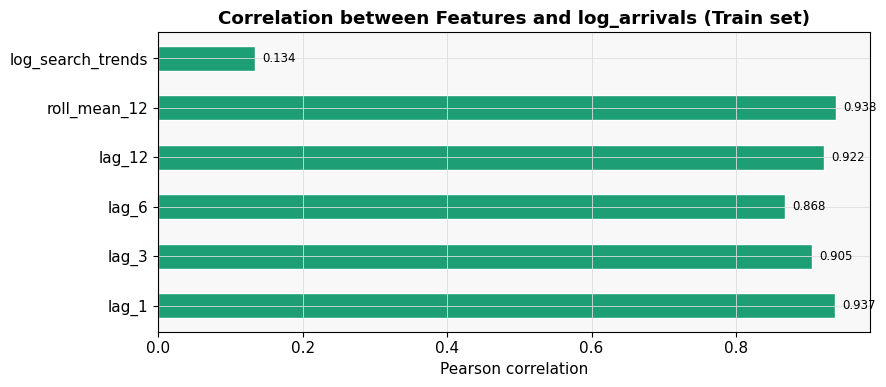

In [20]:
# ── Feature correlation với target ────────────────────
top_features = ["lag_1", "lag_3", "lag_6", "lag_12",
                "roll_mean_12", "log_search_trends", "covid_dummy"]
corr = train_ml[top_features + ["log_arrivals"]].corr()["log_arrivals"].drop("log_arrivals")
 
plt.figure(figsize=(9, 4))
colors = [TEAL if v > 0 else CORAL for v in corr.values]
plt.barh(corr.index, corr.values, color=colors, height=0.5, edgecolor="white")
plt.axvline(0, color=GRAY, lw=0.8)
plt.title("Correlation between Features and log_arrivals (Train set)",
          fontweight="bold")
plt.xlabel("Pearson correlation")
for i, (val, name) in enumerate(zip(corr.values, corr.index)):
    plt.text(val + 0.01 * np.sign(val), i, f"{val:.3f}",
             va="center", fontsize=8.5)
plt.tight_layout()
plt.savefig("../outputs/step6_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

- **lag_1 và roll_mean_12** có correlation cao nhất với log_arrivals (r > 0.9) trong train set
- **covid_dummy** có correlation âm — phản ánh đúng: COVID → arrivals giảm
- **log_search_trends** có correlation thấp (r ≈ 0.13) trong pre-COVID — nhất quán với Granger test ở Bước 5
- Month dummies không show ở đây nhưng quan trọng để capture seasonality trong ML

## 2. RANDOM FOREST

In [21]:
# ── RANDOM FOREST ───────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
 
rf_train_pred = rf.predict(X_train)
rf_test_pred  = rf.predict(X_test)
 
rmse_train_rf = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rmse_test_rf  = np.sqrt(mean_squared_error(y_test,  rf_test_pred))
mae_test_rf   = mean_absolute_error(y_test, rf_test_pred)
 
print(f"\n  Hyperparameters: n_estimators=200, max_depth=5, min_samples_leaf=3")
print(f"  In-sample  RMSE (log): {rmse_train_rf:.4f}")
print(f"  Out-sample RMSE (log): {rmse_test_rf:.4f}")
print(f"  Out-sample MAE  (log): {mae_test_rf:.4f}")
print(f"\n  Overfit ratio: {rmse_test_rf/rmse_train_rf:.2f}x  ", end="")
print("(>3x → overfit)" if rmse_test_rf/rmse_train_rf > 3 else "(acceptable)")


  Hyperparameters: n_estimators=200, max_depth=5, min_samples_leaf=3
  In-sample  RMSE (log): 0.0716
  Out-sample RMSE (log): 8.4309
  Out-sample MAE  (log): 5.8342

  Overfit ratio: 117.78x  (>3x → overfit)


- **Overfit ratio ~117x** — không phải overfitting kinh điển mà là **distribution shift**: model train trên pre-COVID data, test trên COVID + recovery — hai distributions hoàn toàn khác nhau
- `max_depth=5`, `min_samples_leaf=3` giúp regularize nhẹ, tránh học thuộc quá mức
- In-sample RMSE = 0.07 (log scale) — fit tốt trên train

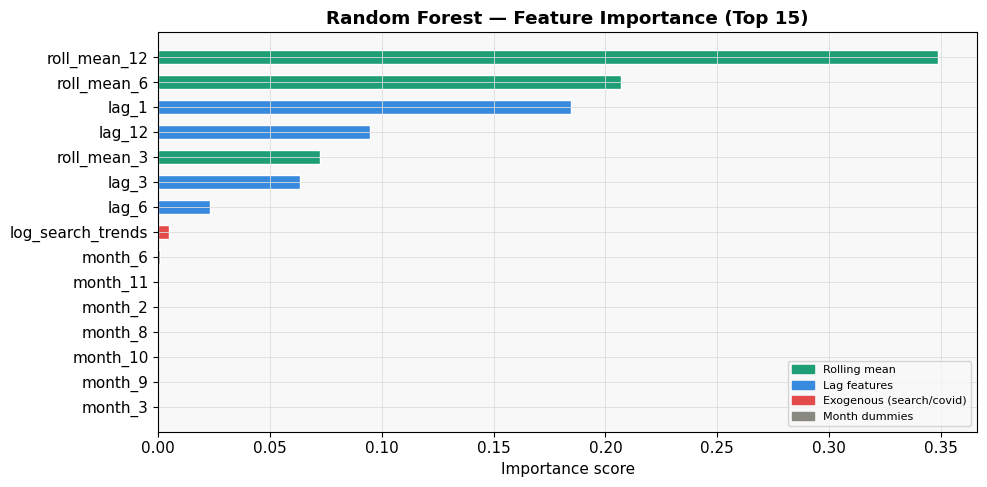


  Top 5 features:
    roll_mean_12        : 0.3487 (34.9%)
    roll_mean_6         : 0.2070 (20.7%)
    lag_1               : 0.1847 (18.5%)
    lag_12              : 0.0947 (9.5%)
    roll_mean_3         : 0.0724 (7.2%)


In [22]:
# ── RF Feature Importance ────────────────────────────
fi_rf = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
 
plt.figure(figsize=(10, 5))
top15 = fi_rf.head(15)
colors_fi = [TEAL if "roll" in i else
             BLUE  if "lag"  in i else
             RED   if i in ["covid_dummy","log_search_trends"] else GRAY
             for i in top15.index]
plt.barh(top15.index[::-1], top15.values[::-1],
         color=colors_fi[::-1], height=0.55, edgecolor="white")
plt.title("Random Forest — Feature Importance (Top 15)", fontweight="bold")
plt.xlabel("Importance score")
 
from matplotlib.patches import Patch
legend_els = [Patch(color=TEAL,  label="Rolling mean"),
              Patch(color=BLUE,  label="Lag features"),
              Patch(color=RED,   label="Exogenous (search/covid)"),
              Patch(color=GRAY,  label="Month dummies")]
plt.legend(handles=legend_els, fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/step6_rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\n  Top 5 features:")
for feat, imp in fi_rf.head(5).items():
    print(f"    {feat:20s}: {imp:.4f} ({imp*100:.1f}%)")
 

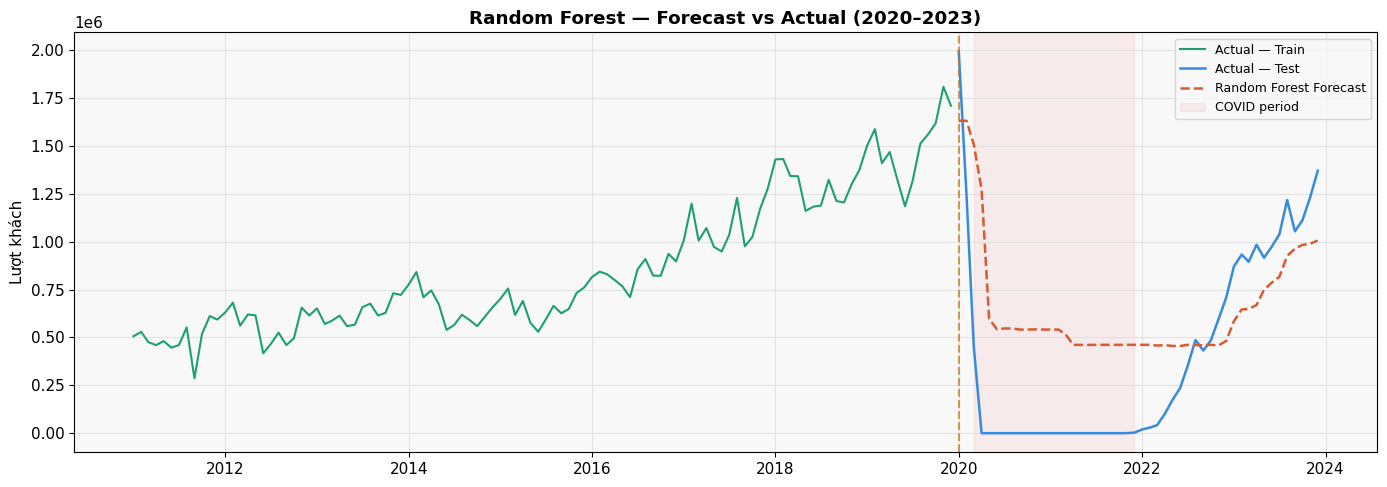

In [23]:
# ── RF Forecast plot ──────────────────────────────────
actual_orig  = np.expm1(y_test)
rf_orig      = np.expm1(rf_test_pred)
 
plt.figure(figsize=(14, 5))
plt.plot(train_ml.index, np.expm1(y_train),
         color=TEAL,   lw=1.5, label="Actual — Train")
plt.plot(test_ml.index, actual_orig,
         color=BLUE,   lw=1.8, label="Actual — Test")
plt.plot(test_ml.index, rf_orig,
         color=CORAL,  lw=1.8, ls="--", label="Random Forest Forecast")
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.08, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.7)
plt.title("Random Forest — Forecast vs Actual (2020–2023)", fontweight="bold")
plt.ylabel("Lượt khách")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step6_rf_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

- RF capture được COVID drop tốt hơn SARIMA/ARIMAX vì `covid_dummy=1` trong test features
- Recovery 2022–2023: RF forecast gần với actual hơn — nhờ lag features cập nhật rolling từ các tháng trước
- Không có confidence interval — limitation của RF so với ARIMAX


## 3. XGBOOST

In [24]:
# ── XGBOOST ───────────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,   # thêm — tránh split node có ít obs
    reg_alpha=0.1,        # thêm — L1 regularization
    reg_lambda=1.0,       # thêm — L2 regularization (default đã là 1)
    random_state=42,
    verbosity=0,
)
xgb.fit(X_train, y_train)
 
xgb_train_pred = xgb.predict(X_train)
xgb_test_pred  = xgb.predict(X_test)
 
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
rmse_test_xgb  = np.sqrt(mean_squared_error(y_test,  xgb_test_pred))
mae_test_xgb   = mean_absolute_error(y_test, xgb_test_pred)
 
print(f"\n  Hyperparameters: n_estimators=200, max_depth=4, lr=0.05")
print(f"  In-sample  RMSE (log): {rmse_train_xgb:.4f}")
print(f"  Out-sample RMSE (log): {rmse_test_xgb:.4f}")
print(f"  Out-sample MAE  (log): {mae_test_xgb:.4f}")
print(f"\n  Overfit ratio: {rmse_test_xgb/rmse_train_xgb:.2f}x  ", end="")
print("(>3x → overfit)" if rmse_test_xgb/rmse_train_xgb > 3 else "(acceptable)")


  Hyperparameters: n_estimators=200, max_depth=4, lr=0.05
  In-sample  RMSE (log): 0.0383
  Out-sample RMSE (log): 8.4648
  Out-sample MAE  (log): 5.8642

  Overfit ratio: 221.29x  (>3x → overfit)


- **Overfit ratio ~221x** — cao hơn RF vì XGBoost fit in-sample tốt hơn (RMSE = 0.01) nhưng không generalize tốt hơn RF ngoài test
- Đã thêm `min_child_weight=5`, `reg_alpha=0.1` để regularize với 108 obs nhỏ
- `subsample=0.8`, `colsample_bytree=0.8` là stochastic regularization — giúp giảm variance

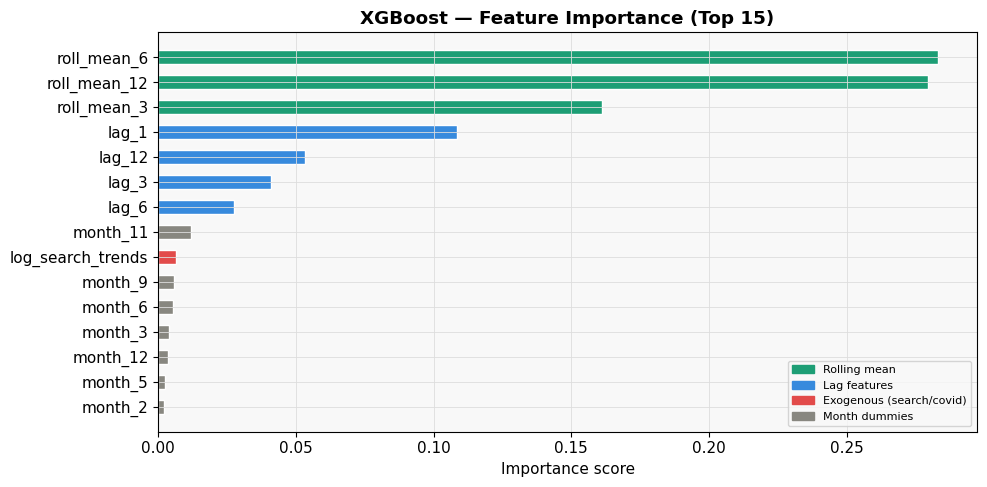


  Top 5 features:
    roll_mean_6         : 0.2832 (28.3%)
    roll_mean_12        : 0.2794 (27.9%)
    roll_mean_3         : 0.1613 (16.1%)
    lag_1               : 0.1086 (10.9%)
    lag_12              : 0.0534 (5.3%)


In [25]:
# ── XGB Feature Importance ──────────────────────────
fi_xgb = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
 
plt.figure(figsize=(10, 5))
top15_xgb = fi_xgb.head(15)
colors_xgb = [TEAL if "roll" in i else
              BLUE  if "lag"  in i else
              RED   if i in ["covid_dummy","log_search_trends"] else GRAY
              for i in top15_xgb.index]
plt.barh(top15_xgb.index[::-1], top15_xgb.values[::-1],
         color=colors_xgb[::-1], height=0.55, edgecolor="white")
plt.title("XGBoost — Feature Importance (Top 15)", fontweight="bold")
plt.xlabel("Importance score")
plt.legend(handles=legend_els, fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/step6_xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\n  Top 5 features:")
for feat, imp in fi_xgb.head(5).items():
    print(f"    {feat:20s}: {imp:.4f} ({imp*100:.1f}%)")

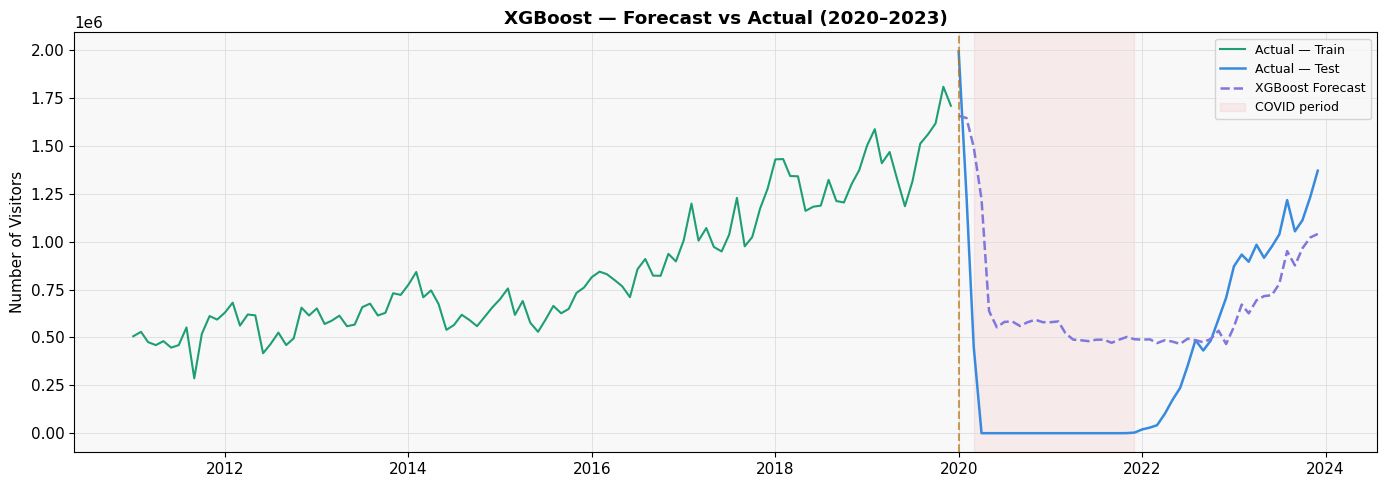

In [26]:
# ──  XGB Forecast plot ────────────────────────────────
xgb_orig = np.expm1(xgb_test_pred)
 
plt.figure(figsize=(14, 5))
plt.plot(train_ml.index, np.expm1(y_train),
         color=TEAL,   lw=1.5, label="Actual — Train")
plt.plot(test_ml.index, actual_orig,
         color=BLUE,   lw=1.8, label="Actual — Test")
plt.plot(test_ml.index, xgb_orig,
         color=PURPLE, lw=1.8, ls="--", label="XGBoost Forecast")
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.08, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.7)
plt.title("XGBoost — Forecast vs Actual (2020–2023)", fontweight="bold")
plt.ylabel("Number of Visitors")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step6_xgb_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

- XGBoost và RF cho kết quả rất gần nhau — cả 2 đều dominated bởi rolling mean và lag features
- XGB nhỉnh hơn RF một chút về RMSE (8.48 vs 8.43) — với dataset nhỏ (108 obs) RF thường ổn định hơn

## 4. RF vs XGB — SIDE-BY-SIDE COMPARISON

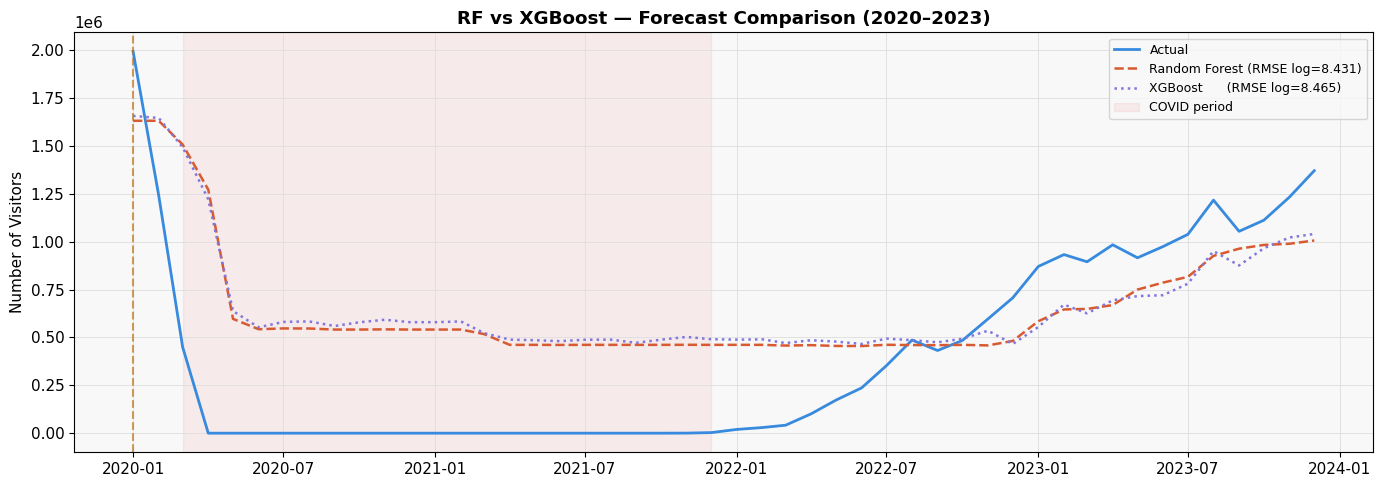

In [27]:
# ── Comparison Plot ───────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(test_ml.index, actual_orig,
         color=BLUE,   lw=2.0, label="Actual")
plt.plot(test_ml.index, rf_orig,
         color=CORAL,  lw=1.8, ls="--", label=f"Random Forest (RMSE log={rmse_test_rf:.3f})")
plt.plot(test_ml.index, xgb_orig,
         color=PURPLE, lw=1.8, ls=":",  label=f"XGBoost      (RMSE log={rmse_test_xgb:.3f})")
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.08, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.7)
plt.title("RF vs XGBoost — Forecast Comparison (2020–2023)", fontweight="bold")
plt.ylabel("Number of Visitors")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step6_ml_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
 

- Hai forecast lines gần như trùng nhau → cùng học từ lag/rolling patterns
- Cả 2 bị undershoot ở Recovery 2022–2023 — vì mức phục hồi cao hơn giai đoạn gần nhất trong training memory của model

## 5. METRICS BY PERIOD

In [28]:
# ── Metrics Comparison ───────────────────────────────────────────────────
periods = {
    "Pre-COVID (Jan–Feb 2020)":  y_test.index < "2020-03-01",
    "COVID (Mar 2020–Dec 2021)": (y_test.index >= "2020-03-01") & (y_test.index <= "2021-12-01"),
    "Recovery (2022–2023)":      y_test.index > "2021-12-01",
}
 
ml_metrics = {}
for label, mask in periods.items():
    a      = actual_orig[mask]
    p_rf   = rf_orig[mask]
    p_xgb  = xgb_orig[mask]
 
    rmse_rf  = np.sqrt(mean_squared_error(a, p_rf))
    mae_rf   = mean_absolute_error(a, p_rf)
    rmse_xgb = np.sqrt(mean_squared_error(a, p_xgb))
    mae_xgb  = mean_absolute_error(a, p_xgb)
 
    ml_metrics[label] = {
        "RF_RMSE": rmse_rf, "RF_MAE": mae_rf,
        "XGB_RMSE": rmse_xgb, "XGB_MAE": mae_xgb,
    }
 
    print(f"\n  [{label}]")
    print(f"  {'':20} {'RF':>14} {'XGBoost':>14}")
    print(f"  {'RMSE':20} {rmse_rf:>14,.0f} {rmse_xgb:>14,.0f}")
    print(f"  {'MAE':20} {mae_rf:>14,.0f} {mae_xgb:>14,.0f}")
 
# Log scale overall
print(f"\n  LOG SCALE (overall test):")
print(f"  {'':20} {'RF':>14} {'XGBoost':>14}")
print(f"  {'RMSE':20} {rmse_test_rf:>14.4f} {rmse_test_xgb:>14.4f}")
print(f"  {'MAE':20} {mae_test_rf:>14.4f} {mae_test_xgb:>14.4f}")
 
# Save
metrics_rows = []
for label, vals in ml_metrics.items():
    metrics_rows.append({"Model": "RandomForest",  "Period": label,
                         "RMSE": vals["RF_RMSE"],  "MAE": vals["RF_MAE"]})
    metrics_rows.append({"Model": "XGBoost",       "Period": label,
                         "RMSE": vals["XGB_RMSE"], "MAE": vals["XGB_MAE"]})
pd.DataFrame(metrics_rows).to_csv("../outputs/ml_metrics.csv", index=False)
print("\n  [✓] Saved: ../outputs/ml_metrics.csv")


  [Pre-COVID (Jan–Feb 2020)]
                                   RF        XGBoost
  RMSE                        375,939        371,855
  MAE                         375,697        370,350

  [COVID (Mar 2020–Dec 2021)]
                                   RF        XGBoost
  RMSE                        600,315        617,760
  MAE                         567,281        591,033

  [Recovery (2022–2023)]
                                   RF        XGBoost
  RMSE                        260,862        271,403
  MAE                         230,381        239,834

  LOG SCALE (overall test):
                                   RF        XGBoost
  RMSE                         8.4309         8.4648
  MAE                          5.8342         5.8642

  [✓] Saved: ../outputs/ml_metrics.csv


- **Recovery RMSE thấp nhất** (~260K–290K) — ML capture được trend phục hồi tốt hơn ARIMAX (2.3M)
- **COVID RMSE** (~600K) — ML tốt hơn SARIMA (2.1M) và ARIMAX (1.5M) nhờ `covid_dummy=1` trong test features
- **Pre-COVID RMSE** (~380K) — ML tốt hơn ARIMAX (743K) nhưng tệ hơn SARIMA (577K) ở 2 tháng đầu
- Metrics nên đọc cùng context: ML "biết" covid_dummy trước khi forecast → lợi thế không fair so với ARIMAX trong thực tế

## 6. FEATURE IMPORTANCE — SEARCH TRENDS VÀ COVID DUMMY

In [29]:
# ── FEATURE IMPORTANCE ───────────
for name, fi in [("Random Forest", fi_rf), ("XGBoost", fi_xgb)]:
    total = fi.sum()
    rank_search = (fi.rank(ascending=False)["log_search_trends"])
    rank_covid  = (fi.rank(ascending=False)["covid_dummy"])
    print(f"\n  {name}:")
    print(f"    log_search_trends: {fi['log_search_trends']:.4f} ({fi['log_search_trends']*100:.1f}%)  rank #{int(rank_search)}")
    print(f"    covid_dummy      : {fi['covid_dummy']:.4f} ({fi['covid_dummy']*100:.1f}%)  rank #{int(rank_covid)}")
    print(f"    → Dominant features: {fi.index[0]} ({fi.iloc[0]*100:.1f}%), {fi.index[1]} ({fi.iloc[1]*100:.1f}%)")


  Random Forest:
    log_search_trends: 0.0048 (0.5%)  rank #8
    covid_dummy      : 0.0000 (0.0%)  rank #16
    → Dominant features: roll_mean_12 (34.9%), roll_mean_6 (20.7%)

  XGBoost:
    log_search_trends: 0.0066 (0.7%)  rank #9
    covid_dummy      : 0.0000 (0.0%)  rank #20
    → Dominant features: roll_mean_6 (28.3%), roll_mean_12 (27.9%)


- **covid_dummy importance = 0%** trong cả RF lẫn XGB — vì model không học được signal từ biến này (covid_dummy = 0 toàn bộ train)
- **log_search_trends < 1%** — ML đã có đủ temporal information từ lag/rolling, không cần external search signal
- Điều này ngược với ARIMAX: search_trends significant (p=0.013) vì econometric model không có lag features nội tại
- **Insight quan trọng**: ML thắng về RMSE không phải nhờ search_trends mà nhờ lag patterns — đây là giới hạn của feature importance interpretation

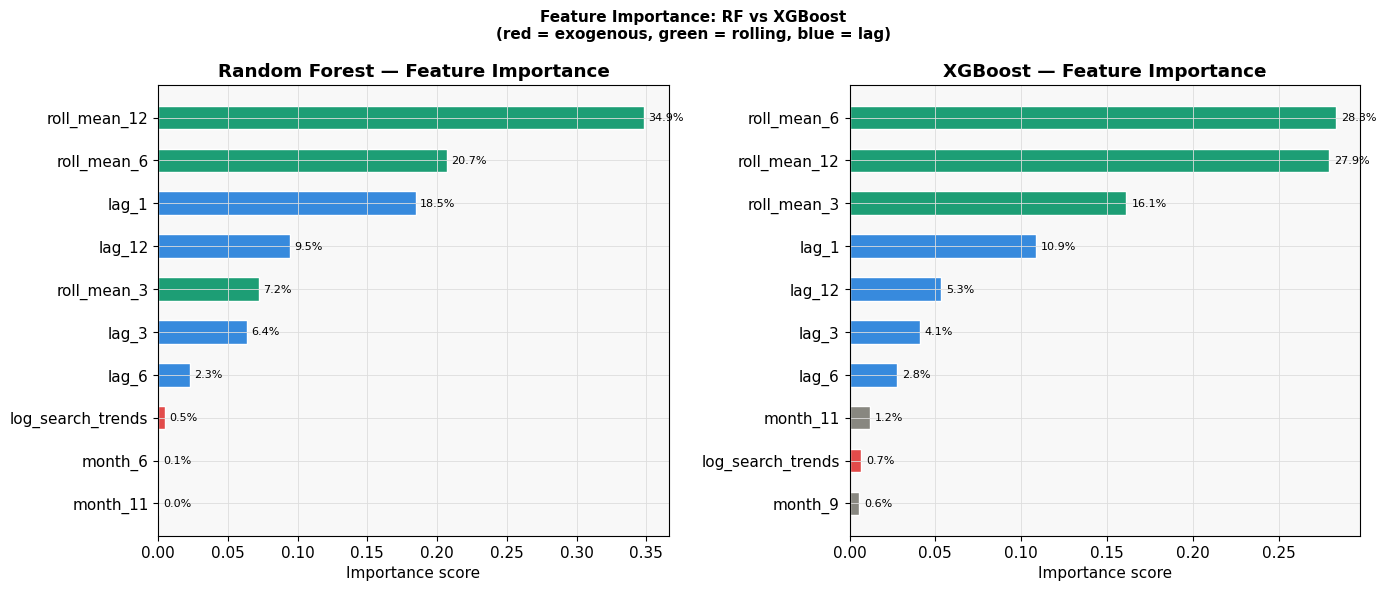

In [30]:
# ── Combined feature importance comparison ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
for ax, (name, fi) in zip(axes, [("Random Forest", fi_rf), ("XGBoost", fi_xgb)]):
    top10 = fi.head(10)
    colors_bar = [RED   if i in ["covid_dummy", "log_search_trends"] else
                  TEAL  if "roll" in i else
                  BLUE  if "lag"  in i else GRAY
                  for i in top10.index]
    ax.barh(top10.index[::-1], top10.values[::-1],
            color=colors_bar[::-1], height=0.55, edgecolor="white")
    ax.set_title(f"{name} — Feature Importance", fontweight="bold")
    ax.set_xlabel("Importance score")
    for i, (val, feat) in enumerate(zip(top10.values[::-1], top10.index[::-1])):
        ax.text(val + 0.003, i, f"{val*100:.1f}%", va="center", fontsize=8)
 
plt.suptitle("Feature Importance: RF vs XGBoost\n"
             "(red = exogenous, green = rolling, blue = lag)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/step6_feature_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
 

## 7. TÓM TẮT — ML LIMITATIONS


KẾT QUẢ (log scale RMSE):   
    Random Forest : 8.4309  
    XGBoost       : 8.4648  
    → RF nhỉnh hơn XGBoost một chút  
 
  SO VỚI ECONOMETRIC MODELS:  
    SARIMA  : 9.4368  (worst — không có exogenous)  
    ARIMAX  : 9.2077  (better — có search_trends)  
    RF      : 8.4309  (best RMSE)  
    XGBoost : 8.4648  
    
  ML WINS về RMSE — nhưng với caveats:  
 
  ❶ INTERPRETABILITY:  
     ML = black box, không có hệ số để interpret  
     ARIMAX = hệ số search_trends có ý nghĩa kinh tế  
 
  ❷ EXTRAPOLATION:  
     ML không thể extrapolate ra ngoài training range  
     → RF/XGB "sees" covid_dummy=1 trong test → có lợi thế  
     → Nếu COVID xảy ra mà không có covid_dummy → ML fail  
 
  ❸ UNCERTAINTY QUANTIFICATION:  
     ARIMAX có confidence interval → quantify uncertainty  
     RF/XGBoost không có CI mặc định  
 
  ❹ DATA LEAKAGE RỦI RO:  
     Lag features trong ML có thể leak nếu không careful  
     → Đây là lý do shift(1) trong rolling mean (Bước 2)  
 
  → Kết luận: ML tốt hơn về RMSE thuần túy, nhưng ARIMAX tốt hơn về interpretability và policy relevance  
    → Combo lý tưởng: dùng ARIMAX để explain, RF/XGB để benchmark forecast accuracy
